In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Panel A

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/original/checkpoints/CordBloodDynamicRates/0603_121235/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [5]:
cluster_names = [
    'HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
    'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
    'Monocyte', 'DC precursor', 'DC'
]

In [6]:
gillespie_dir='./trials/original/checkpoints/CordBloodDynamicGillespie/0605_131252/models/'
gillespie_dir_valid = os.path.join(gillespie_dir, 'clone_1')

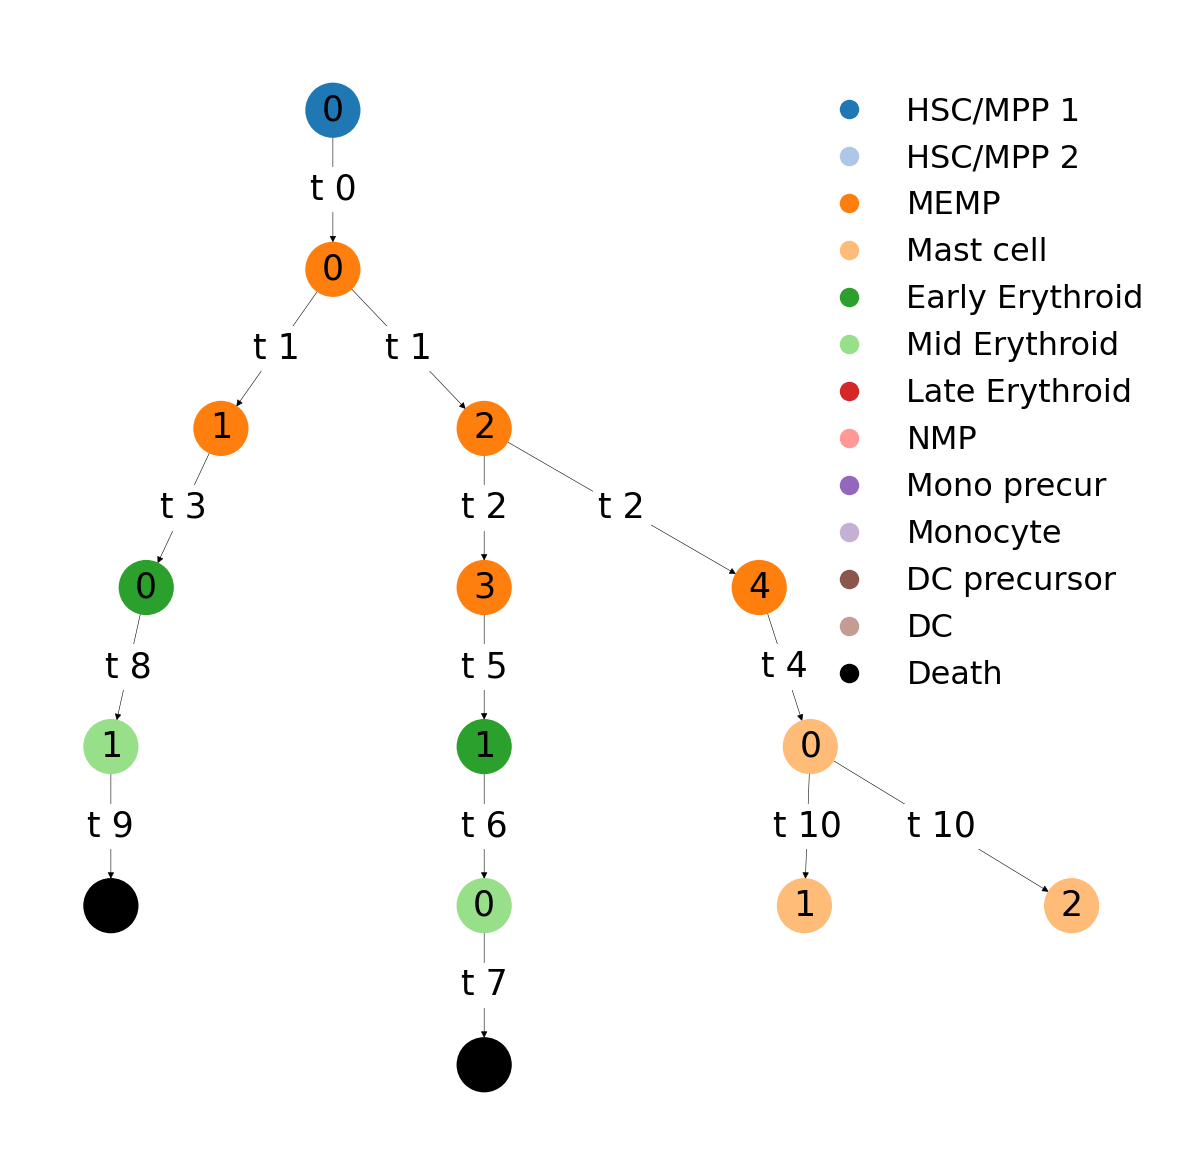

In [9]:
from clonaltrans.pl import visualize_gtree
visualize_gtree(
    11, 
    cluster_names, 
    gillespie_dir=gillespie_dir_valid, 
    show=True
)

### Panel B

In [10]:
from clonaltrans.pl import get_num_div
from natsort import natsorted

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        get_num_div(cluster_names, gillespie_dir=gillespie_dir_clones)

Total # of gillespie trials for ['models', 'clone_0']: 980
Total # of gillespie trials for ['models', 'clone_1']: 951
Total # of gillespie trials for ['models', 'clone_2']: 970
Total # of gillespie trials for ['models', 'clone_3']: 982
Total # of gillespie trials for ['models', 'clone_4']: 958
Total # of gillespie trials for ['models', 'clone_5']: 946
Total # of gillespie trials for ['models', 'clone_6']: 957
Total # of gillespie trials for ['models', 'clone_7']: 957
Total # of gillespie trials for ['models', 'clone_8']: 954
Total # of gillespie trials for ['models', 'clone_9']: 966
Total # of gillespie trials for ['models', 'clone_10']: 930
Total # of gillespie trials for ['models', 'clone_11']: 927
Total # of gillespie trials for ['models', 'clone_12']: 999


In [11]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []
length, mean, num_trails = [], [], []

for clone in range(model.N.shape[1]):
    distribution, counts = get_div_distribution(os.path.join(gillespie_dir, f'clone_{clone}'), cluster_names)
    distributions.append(distribution)
    num_trails.append(counts)

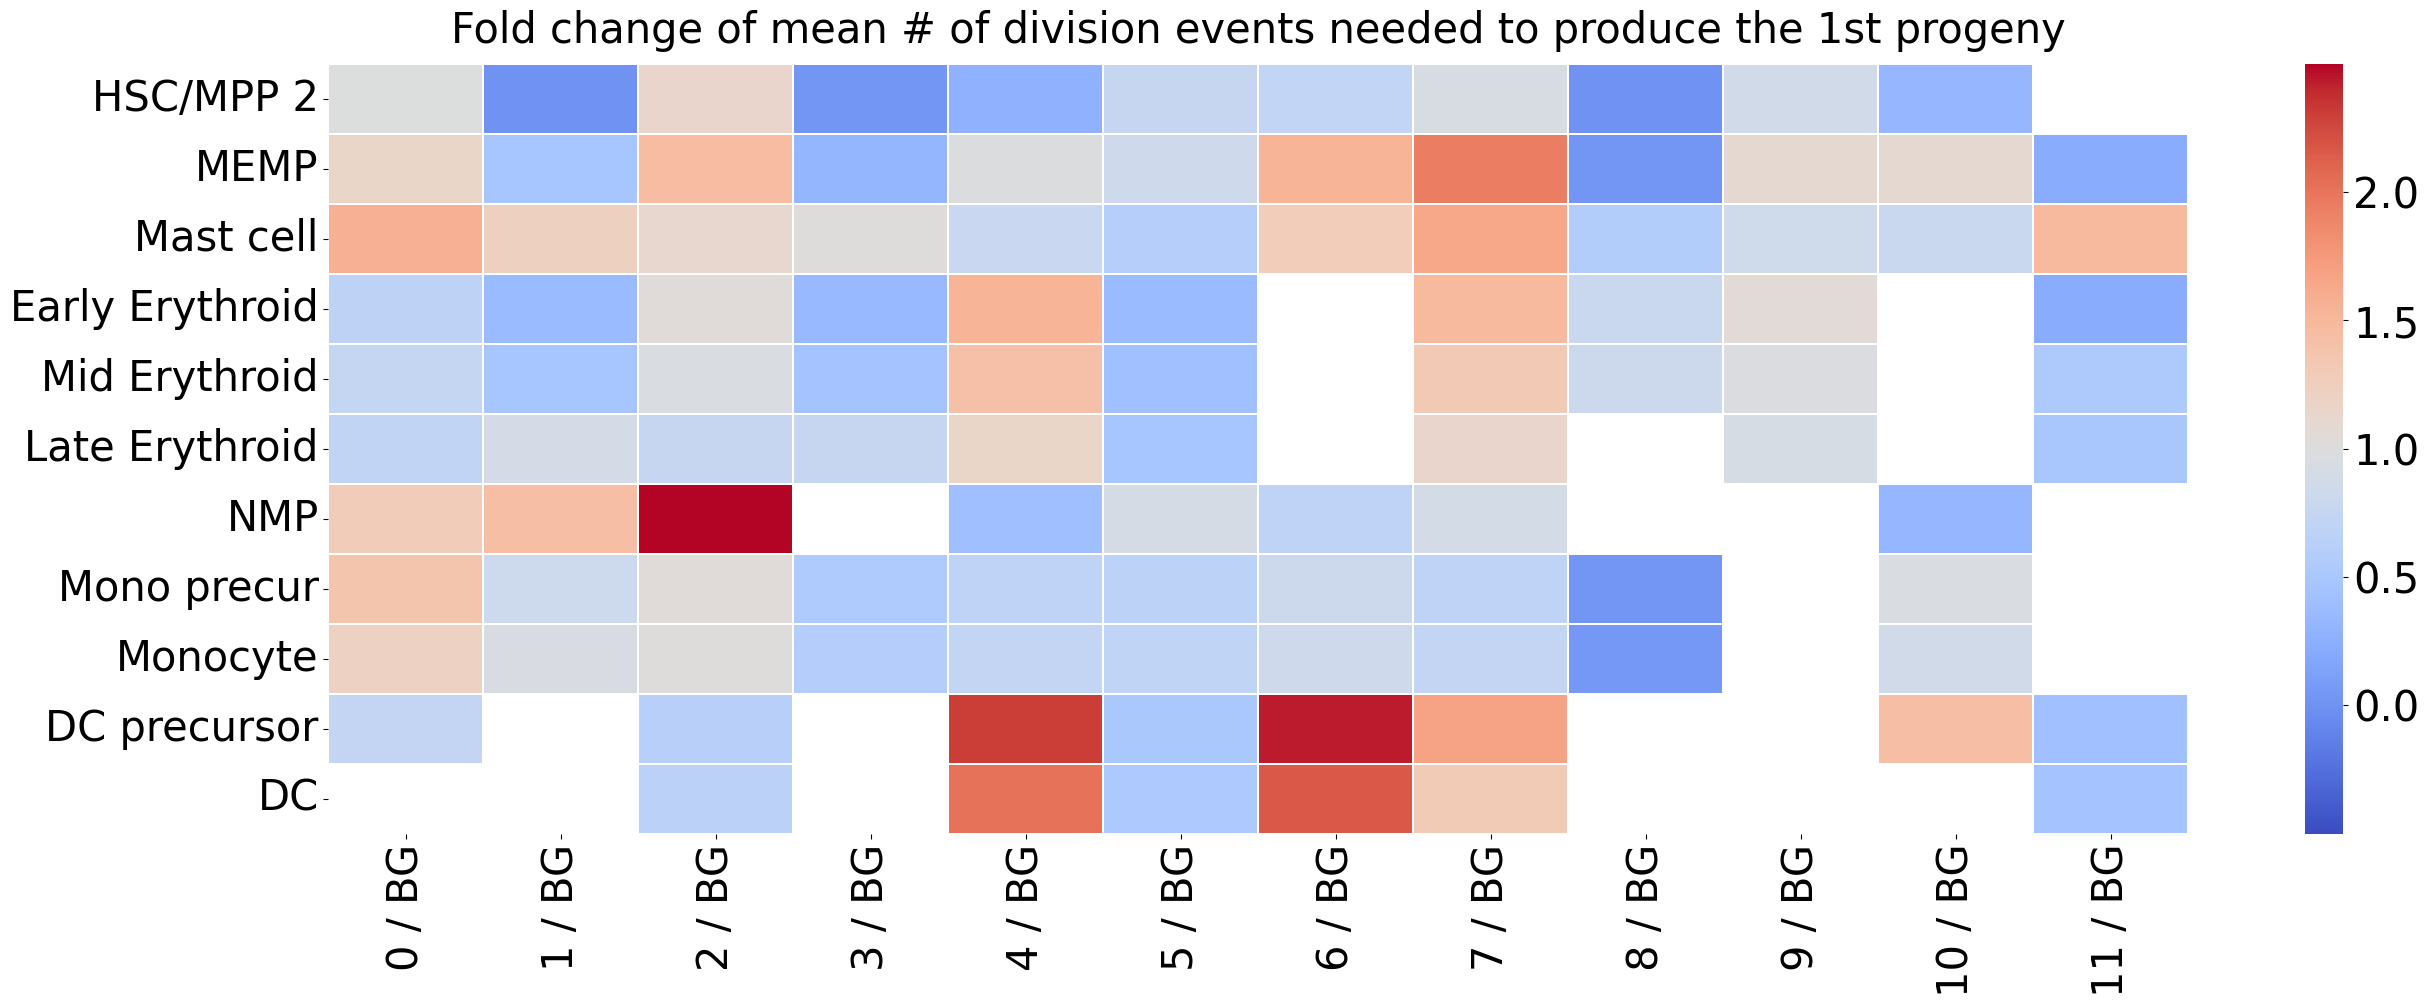

In [19]:
from clonaltrans.pl import clone_dist_diff_plot
clone_dist_diff_plot(distributions, model)

### Panel C

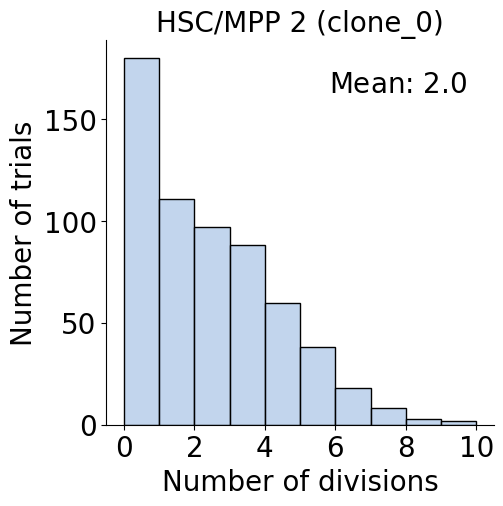

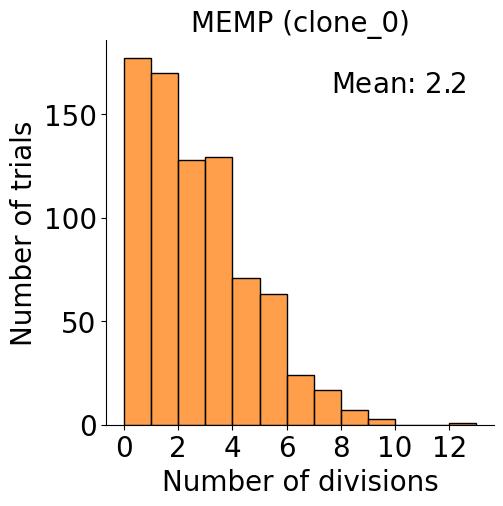

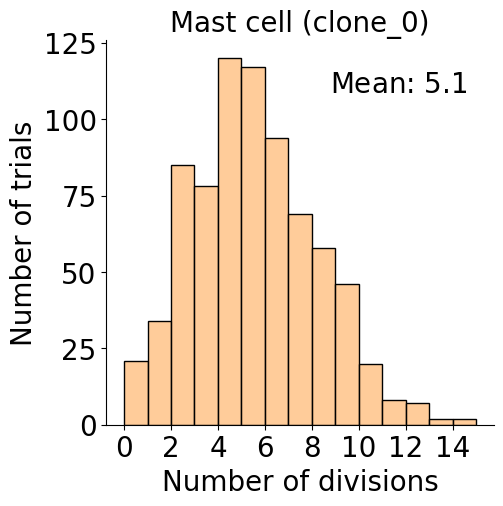

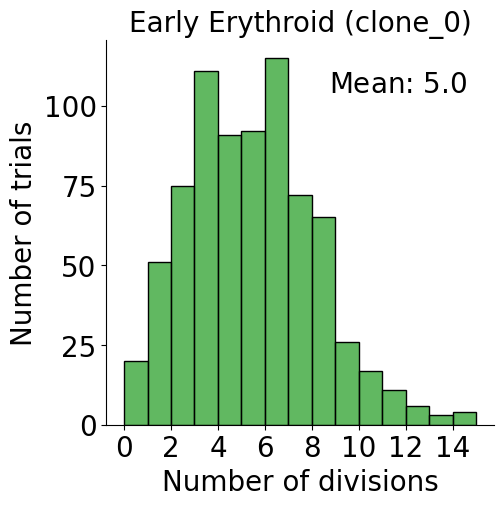

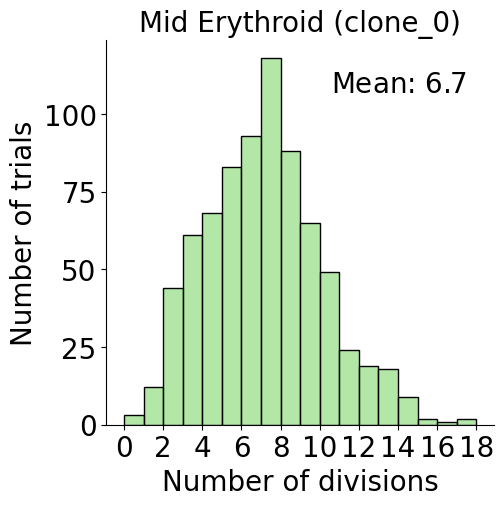

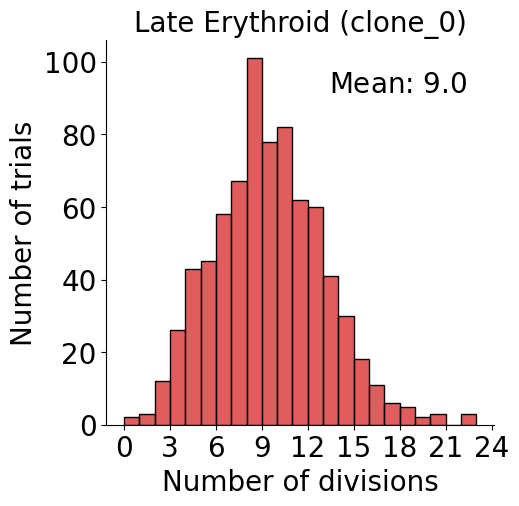

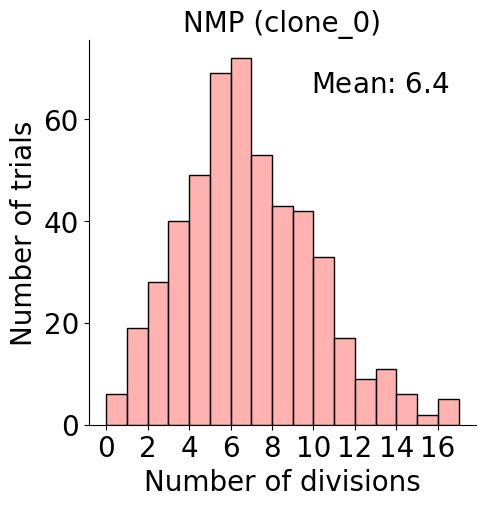

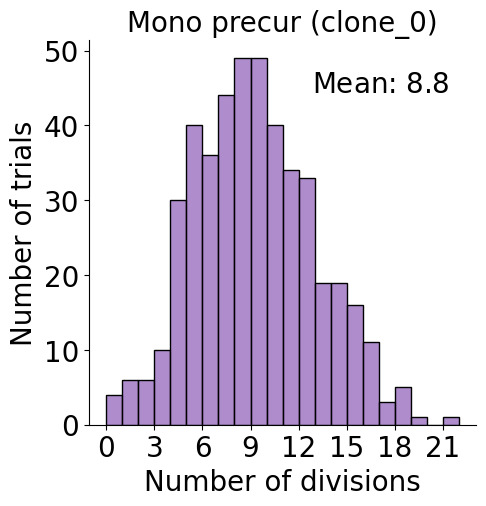

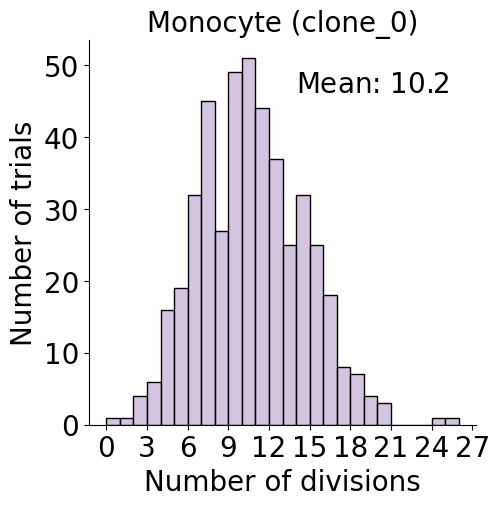

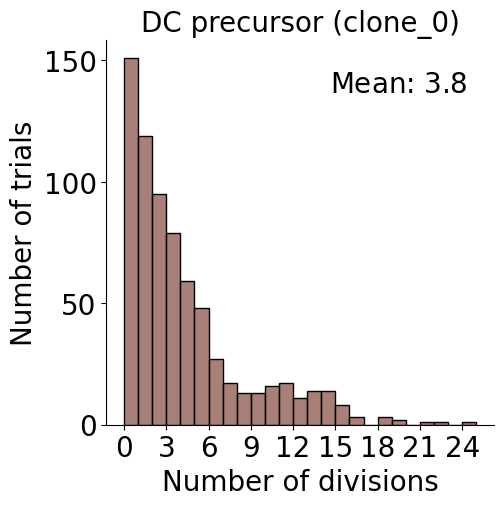

In [22]:
from clonaltrans.pl import visualize_num_div
gillespie_dir_valid = os.path.join(gillespie_dir, 'clone_0')
visualize_num_div(cluster_names, gillespie_dir=gillespie_dir_valid, clone_name='clone_0')

### Panel D

In [23]:
length = copy.deepcopy(distributions)

for clone in length:
    for key in clone.keys():
        clone[key] = len(clone[key])

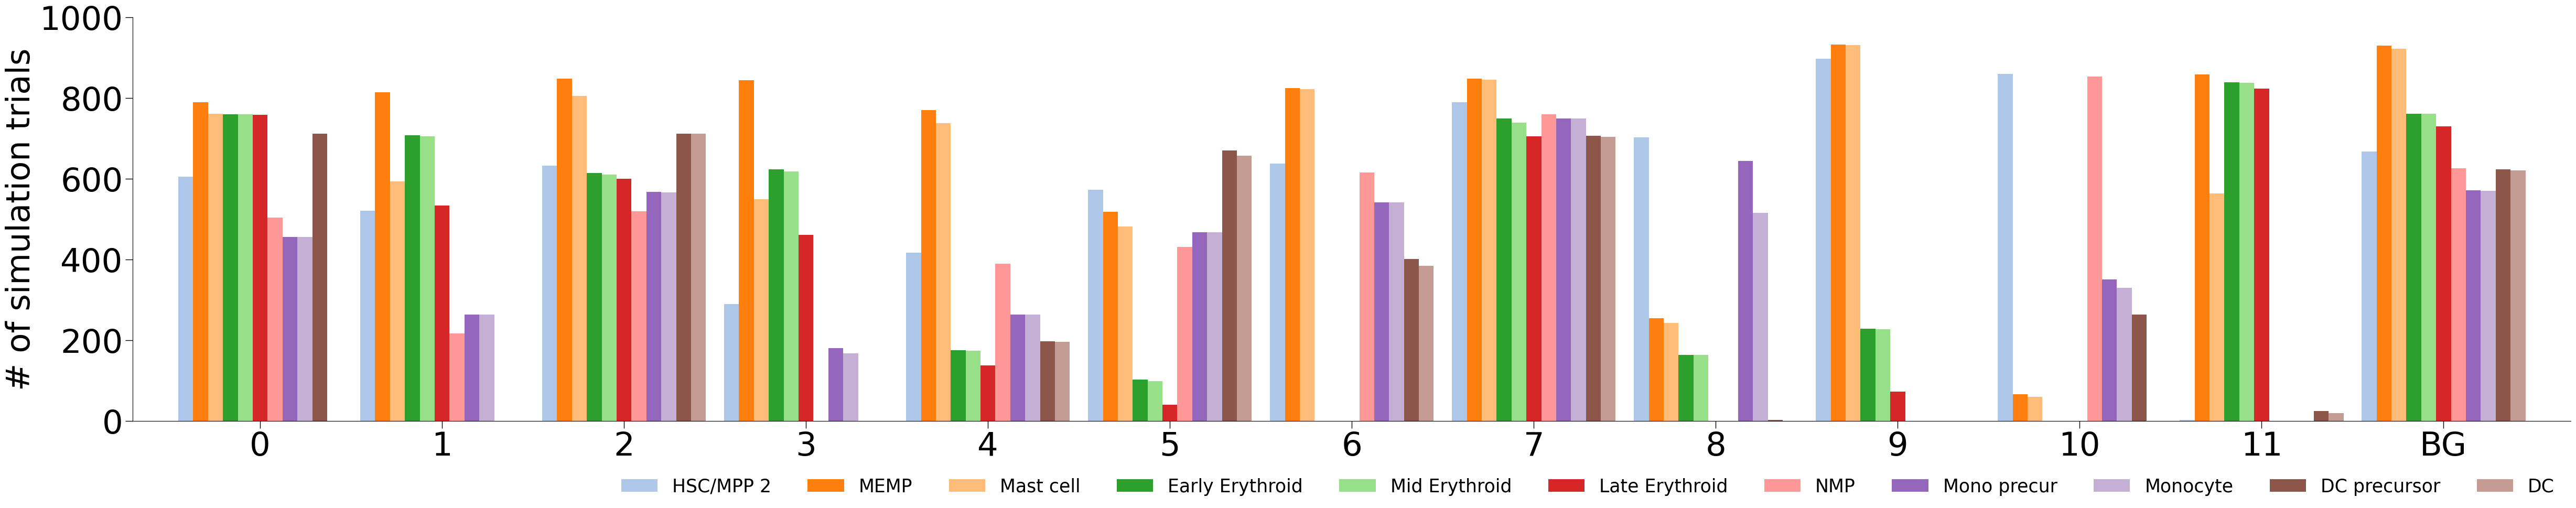

In [26]:
from clonaltrans.pl import succeed_trails_to_first
succeed_trails_to_first(length, num_trails)